In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("data/student-mat.csv", sep=";")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [4]:
print("Missing values:")
print(df.isnull().sum().sum())

Missing values:
0


In [5]:
print(df["G3"].describe())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


In [6]:
X = df.drop(columns=["G3"])
y = df["G3"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (395, 32)
Target shape: (395,)


In [7]:
X = pd.get_dummies(X, drop_first=True)
print("Encoded feature shape:", X.shape)
X.head()

Encoded feature shape: (395, 41)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 316
Testing samples: 79


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
linear_model = LinearRegression()

In [11]:
linear_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [12]:
y_pred_lr = linear_model.predict(X_test)
print("Predictions generated successfully.")
print(y_pred_lr[:10])

Predictions generated successfully.
[ 6.00160699 11.52847844  2.86643677  8.79663116  8.55310627 11.88964112
 19.09674195  7.17307901  7.4050707  12.31153657]


In [13]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 1.6466656197147496
MSE : 5.65664283323122
RMSE: 2.3783697847961363
R²  : 0.7241341236974023


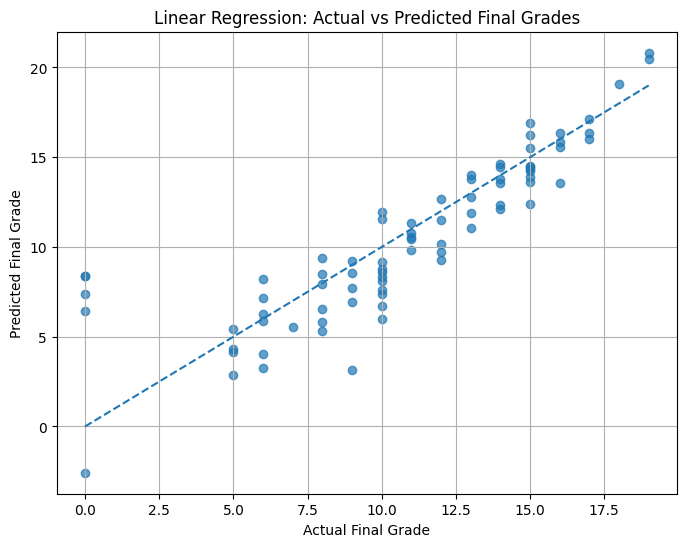

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Linear Regression: Actual vs Predicted Final Grades")
plt.grid(True)
plt.savefig("results/lr_actual_vs_predicted.png",dpi=300,bbox_inches="tight")
plt.show()

In [16]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_lr],
    "MSE": [mse_lr],
    "RMSE": [rmse_lr],
    "R²": [r2_lr]
})

comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,1.646666,5.656643,2.37837,0.724134


In [17]:
# Model Comparison: Linear Regression vs ANN

comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Linear Regression": [
        1.6466656197147496,
        5.65664283323122,
        2.3783697847961363,
        0.7241341236974023
    ],
    "ANN": [
        1.7753,
        5.9061,
        2.4302,
        0.7120
    ]
})

print(comparison)

  Metric  Linear Regression     ANN
0    MAE           1.646666  1.7753
1    MSE           5.656643  5.9061
2   RMSE           2.378370  2.4302
3     R²           0.724134  0.7120
